# Notebook 3 — Isolation Forest and Final Comparison

## Objective
This notebook introduces Isolation Forest, an unsupervised machine
learning method for anomaly detection that requires no assumption
about the distribution of the data.

We apply it to the same synthetic dataset used in Notebooks 1 and 2,
then build a final comparison table of all three methods.

## Mathematical Foundation

Isolation Forest builds an ensemble of random decision trees called
isolation trees. Each tree randomly selects a feature and a split
value to partition the data.

The anomaly score is based on the average path length to isolate
a point across all trees:

- Short path length → point is easy to isolate → anomaly
- Long path length → point is hard to isolate → normal

The score is normalized between 0 and 1:
- Score close to 1 → very likely anomaly
- Score close to 0.5 → normal observation

## Key Question
How does Isolation Forest compare to z-score and MAD on the same data?

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Recreate the same dataset as Notebooks 1 and 2
np.random.seed(42)

n_patients = 200
mu = 70
sigma = 5

# Normal data
data = np.random.normal(loc=mu, scale=sigma, size=n_patients)

# Inject same anomalies
low_anomalies = np.random.normal(40, 2, 5)
high_anomalies = np.random.normal(110, 2, 5)
anomalies = np.concatenate([low_anomalies, high_anomalies])

# Combined dataset
data_with_anomalies = np.concatenate([data, anomalies])

# Also recompute classical and MAD scores for final comparison
mean = data_with_anomalies.mean()
std = data_with_anomalies.std()
classical_z_scores = (data_with_anomalies - mean) / std

median = np.median(data_with_anomalies)
mad = np.median(np.abs(data_with_anomalies - median))
modified_z_scores = 0.6745 * (data_with_anomalies - median) / mad

print(f"Dataset recreated: {len(data_with_anomalies)} observations")
print(f"Anomaly values: {anomalies.round(2)}")

Dataset recreated: 210 observations
Anomaly values: [ 40.72  41.12  42.17  42.11  37.24 108.12 111.03 111.03 111.03 117.71]


In [3]:
# Apply Isolation Forest
# Reshape data to 2D array — scikit-learn requires this format
X = data_with_anomalies.reshape(-1, 1)

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,      # number of isolation trees
    contamination=0.05,    # expected proportion of anomalies (10/210 ≈ 0.05)
    random_state=42
)

iso_forest.fit(X)

# Get predictions and anomaly scores
predictions = iso_forest.predict(X)      # 1 = normal, -1 = anomaly
anomaly_scores = iso_forest.decision_function(X)  # higher = more normal

# Convert predictions to boolean mask
iso_anomaly_mask = predictions == -1

n_detected_iso = iso_anomaly_mask.sum()

print(f"Isolation Forest detected: {n_detected_iso} anomalies")
print(f"\nValues detected:")
print(f"{data_with_anomalies[iso_anomaly_mask].round(2)}")

Isolation Forest detected: 11 anomalies

Values detected:
[ 56.9   83.6   40.72  41.12  42.17  42.11  37.24 108.12 111.03 111.03
 117.71]


In [4]:
# Identify false positives
# True anomalies are the last 10 points (indices 200-209)
true_anomaly_indices = set(range(200, 210))
detected_indices = set(np.where(iso_anomaly_mask)[0])

false_positives = detected_indices - true_anomaly_indices
false_negatives = true_anomaly_indices - detected_indices

print(f"True anomaly indices: {sorted(true_anomaly_indices)}")
print(f"Detected indices:     {sorted(detected_indices)}")
print(f"\nFalse positives (normal points flagged): {false_positives}")
print(f"False negatives (anomalies missed):      {false_negatives}")

if false_positives:
    fp_values = data_with_anomalies[list(false_positives)]
    fp_z = classical_z_scores[list(false_positives)]
    print(f"\nFalse positive value:   {fp_values.round(2)}")
    print(f"Its classical z-score:  {fp_z.round(2)}")

True anomaly indices: [200, 201, 202, 203, 204, 205, 206, 207, 208, 209]
Detected indices:     [np.int64(74), np.int64(179), np.int64(200), np.int64(201), np.int64(202), np.int64(203), np.int64(204), np.int64(205), np.int64(207), np.int64(208), np.int64(209)]

False positives (normal points flagged): {np.int64(74), np.int64(179)}
False negatives (anomalies missed):      {206}

False positive value:   [56.9 83.6]
Its classical z-score:  [-1.45  1.48]


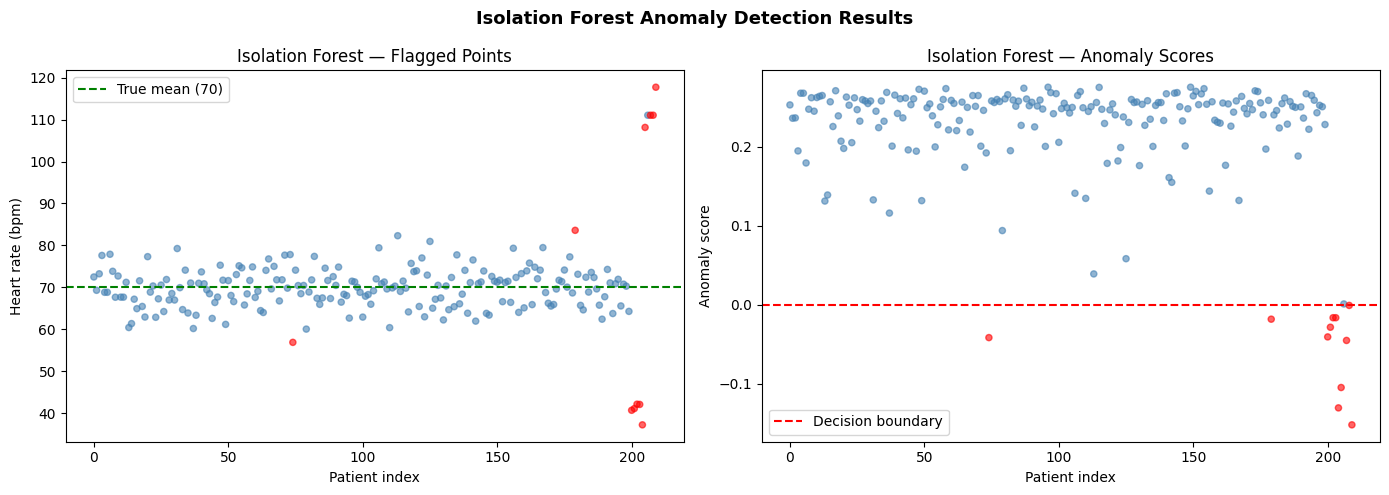

Figure saved.


In [5]:
# Visualize Isolation Forest results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_iso = ['red' if f else 'steelblue' for f in iso_anomaly_mask]

# Plot 1 — Raw data with flagged points
axes[0].scatter(range(len(data_with_anomalies)), data_with_anomalies,
                c=colors_iso, alpha=0.6, s=20)
axes[0].axhline(mu, color='green', linestyle='--', label='True mean (70)')
axes[0].set_title('Isolation Forest — Flagged Points')
axes[0].set_xlabel('Patient index')
axes[0].set_ylabel('Heart rate (bpm)')
axes[0].legend()

# Plot 2 — Anomaly scores
colors_scores = ['red' if f else 'steelblue' for f in iso_anomaly_mask]
axes[1].scatter(range(len(anomaly_scores)), anomaly_scores,
                c=colors_scores, alpha=0.6, s=20)
axes[1].axhline(0, color='red', linestyle='--', label='Decision boundary')
axes[1].set_title('Isolation Forest — Anomaly Scores')
axes[1].set_xlabel('Patient index')
axes[1].set_ylabel('Anomaly score')
axes[1].legend()

plt.suptitle('Isolation Forest Anomaly Detection Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig04_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved.")

In [6]:
# Final comparison of all three methods
threshold = 3

# Classical z-score mask
classical_mask = np.abs(classical_z_scores) > threshold

# MAD mask
mad_mask = np.abs(modified_z_scores) > threshold

# True anomaly indices
true_anomaly_indices = set(range(200, 210))

def evaluate(mask, true_indices, total):
    detected = set(np.where(mask)[0])
    tp = len(detected & true_indices)
    fp = len(detected - true_indices)
    fn = len(true_indices - detected)
    return tp, fp, fn

tp_c, fp_c, fn_c = evaluate(classical_mask, true_anomaly_indices, len(data_with_anomalies))
tp_m, fp_m, fn_m = evaluate(mad_mask, true_anomaly_indices, len(data_with_anomalies))
tp_i, fp_i, fn_i = evaluate(iso_anomaly_mask, true_anomaly_indices, len(data_with_anomalies))

# Build comparison dataframe
comparison = pd.DataFrame({
    'Method': ['Z-Score', 'MAD', 'Isolation Forest'],
    'True Positives': [tp_c, tp_m, tp_i],
    'False Positives': [fp_c, fp_m, fp_i],
    'False Negatives': [fn_c, fn_m, fn_i],
    'Total Detected': [classical_mask.sum(), mad_mask.sum(), iso_anomaly_mask.sum()]
})

print("=" * 55)
print("   FINAL COMPARISON — ALL THREE METHODS")
print("=" * 55)
print(comparison.to_string(index=False))
print("=" * 55)
print(f"\nTrue anomalies injected: 10")

   FINAL COMPARISON — ALL THREE METHODS
          Method  True Positives  False Positives  False Negatives  Total Detected
         Z-Score              10                0                0              10
             MAD              10                0                0              10
Isolation Forest               9                2                1              11

True anomalies injected: 10


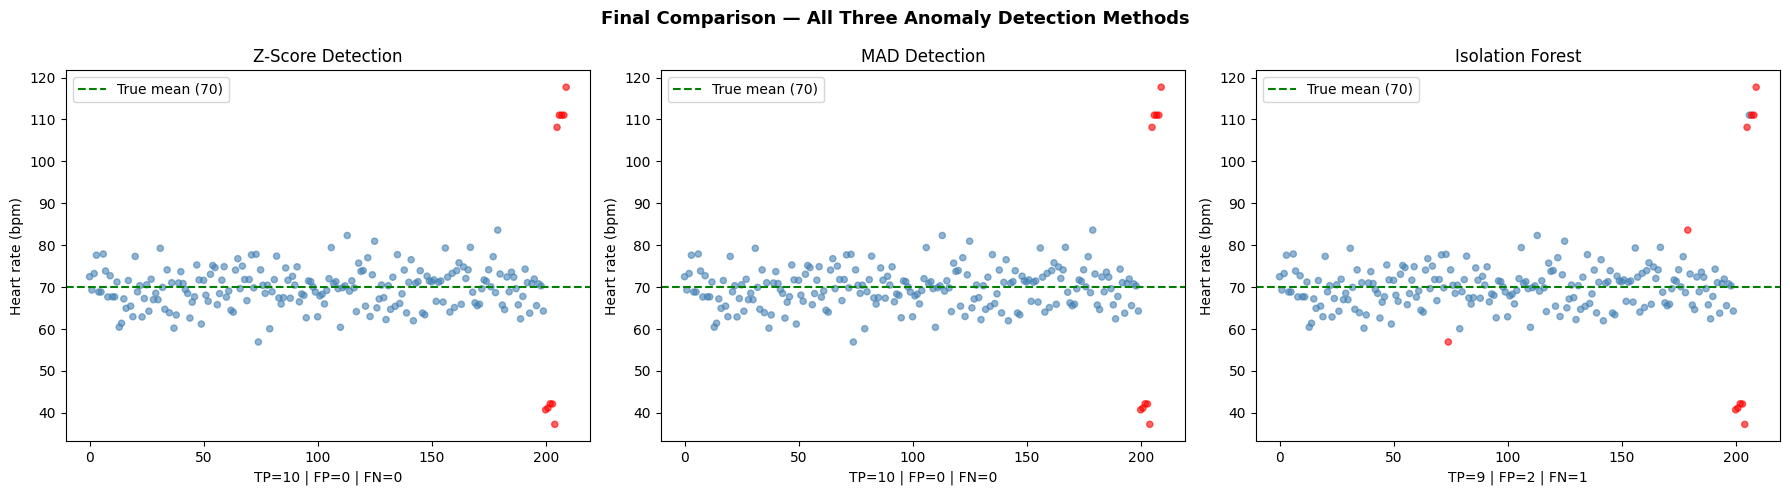

Figure saved.


In [7]:
# Visualize final comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

masks = [classical_mask, mad_mask, iso_anomaly_mask]
titles = ['Z-Score Detection', 'MAD Detection', 'Isolation Forest']

for i, (mask, title) in enumerate(zip(masks, titles)):
    colors = ['red' if f else 'steelblue' for f in mask]
    axes[i].scatter(range(len(data_with_anomalies)), data_with_anomalies,
                    c=colors, alpha=0.6, s=20)
    axes[i].axhline(mu, color='green', linestyle='--', label='True mean (70)')
    axes[i].set_title(title)
    axes[i].set_xlabel('Patient index')
    axes[i].set_ylabel('Heart rate (bpm)')

    # Annotate with results
    tp, fp, fn = evaluate(mask, true_anomaly_indices, len(data_with_anomalies))
    axes[i].set_xlabel(f'TP={tp} | FP={fp} | FN={fn}')
    axes[i].legend()

plt.suptitle('Final Comparison — All Three Anomaly Detection Methods',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig05_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved.")

## Final Results and Interpretation

### What we built across three notebooks
We applied three progressively sophisticated anomaly detection
methods to the same synthetic dataset of 210 observations
(200 normal + 10 injected anomalies) simulating patient heart rates.

### Final comparison

| Method | True Positives | False Positives | False Negatives |
|---|---|---|---|
| Z-Score | 10 | 0 | 0 |
| MAD | 10 | 0 | 0 |
| Isolation Forest | 9 | 2 | 1 |

### What this tells us

**Z-Score and MAD** both achieved perfect detection on this dataset.
The key difference between them is not visible here — it will emerge
on noisier data where anomalies are subtler. MAD is theoretically
more robust because its boundaries are not distorted by the anomalies
themselves.

**Isolation Forest** produced 2 false positives and missed 1 anomaly.
On this small, clean, one-dimensional dataset this is a limitation.
However, Isolation Forest makes no assumption about the distribution
of the data — its true advantage will appear on real multivariate
medical data where distributions are unknown and complex.

### Honest limitations of this study
- All three methods were tested on synthetic data only
- The anomalies were deliberately obvious (40 bpm and 110 bpm
  against a mean of 70 bpm)
- Results on real physiological data (PhysioNet) may differ
  significantly
- This study is one-dimensional — real medical data is multivariate

### What comes next
The natural next step is to apply these methods to real open
physiological datasets such as those available on PhysioNet,
where data are noisy, multivariate, and anomalies are not
known in advance.